# Random forest

<center>
  <img src="https://miro.medium.com/max/1170/1*58f1CZ8M4il0OZYg2oRN4w.png"/><br>
  image from: <a href="https://medium.com/@ar.ingenious/applying-random-forest-classification-machine-learning-algorithm-from-scratch-with-real-24ff198a1c57">APPLYING RANDOM FOREST (CLASSIFICATION) — MACHINE LEARNING ALGORITHM FROM SCRATCH WITH REAL DATASETS</a>
</center>

- by [<img src="https://scikit-learn.org/stable/_static/scikit-learn-logo-small.png" height="32"/> scikit-learn (RandomForestClassifier)](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html#sklearn.ensemble.RandomForestClassifier)

## สร้าง DataFrame

- ใช้ dataset จากไฟล์ `winequality.csv`
  1. **Fixed Acidity (ความเป็นกรดคงที่):** ปริมาณกรดในไวน์ที่ไม่ระเหยได้ง่าย มีความสำคัญในการให้รสชาติเปรี้ยว

  2. **Volatile Acidity (ความเป็นกรดระเหย):** ปริมาณกรดที่ระเหยได้ง่ายเช่น กรดแอซิติก ถ้ามีปริมาณมากเกินไปจะทำให้ไวน์มีกลิ่นเหมือนน้ำส้มสายชู

  3. **Citric Acid (กรดซิตริก):** กรดที่พบในผลไม้ ให้รสชาติเปรี้ยวสดชื่นและช่วยเพิ่มความสดของไวน์

  4. **Residual Sugar (น้ำตาลที่เหลืออยู่):** ปริมาณน้ำตาลที่ยังเหลืออยู่หลังจากการหมัก ไวน์ที่มีน้ำตาลเหลือมากจะมีรสหวาน

  5. **Chlorides (คลอไรด์):** ปริมาณเกลือในไวน์ ถ้ามีปริมาณมากเกินไปจะทำให้ไวน์มีรสเค็ม

  6. **Free Sulfur Dioxide (ซัลเฟอร์ไดออกไซด์อิสระ):** ปริมาณซัลเฟอร์ไดออกไซด์ในไวน์ที่ไม่ได้ทำปฏิกิริยากับสารอื่นๆ ช่วยป้องกันไวน์จากการออกซิเดชันและการเสียหายจากเชื้อรา

  7. **Total Sulfur Dioxide (ซัลเฟอร์ไดออกไซด์ทั้งหมด):** ปริมาณรวมของซัลเฟอร์ไดออกไซด์ทั้งที่อิสระและที่ทำปฏิกิริยากับสารอื่นๆในไวน์

  8. **Density (ความหนาแน่น):** ความหนาแน่นของไวน์ ซึ่งมีความสัมพันธ์กับปริมาณน้ำตาลและแอลกอฮอล์ในไวน์

  9. **pH (ค่าความเป็นกรด-ด่าง):** ค่าที่แสดงความเป็นกรดหรือเบสของไวน์ ไวน์ทั่วไปจะมีค่า pH อยู่ระหว่าง 3 ถึง 4

  10. **Sulphates (ซัลเฟต):** สารประกอบที่ช่วยเพิ่มกลิ่นหอมของไวน์และป้องกันการเกิดออกซิเดชัน

  11. **Alcohol (แอลกอฮอล์):** ปริมาณแอลกอฮอล์ในไวน์ มีผลต่อรสชาติและความรู้สึกเมา

  12. **Quality (คุณภาพ):** คุณภาพของไวน์ 0 - Bad Wine, 1 - Good Wine

- อัพโหลดขึ้น Google drive หรือเรียกใช้จาก [https://raw.githubusercontent.com/AjKaew/DGA306/main/winequality.csv](https://raw.githubusercontent.com/AjKaew/DGA306/main/winequality.csv)
- เรียกใช้ `pandas`
- อ่านไฟล์ `winequality.csv`

```python
wine_df = pd.read_csv('/path to file/winequality.csv')
```

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
wine_df = pd.read_csv('/content/drive/MyDrive/ML dataset/winequality-red (binary).csv')
wine_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0


- ตรวจสอบจำนวน class

```python
wine_df.quality.value_counts()
```

In [ ]:
wine_df.quality.value_counts()

,count
quality,
1,855
0,744


- ในที่นี้ต้องการทำนาย `quality`

```python
X = wine_df.drop(['quality'], axis=1)
y = wine_df.quality
```

In [ ]:
X = wine_df.drop(['quality'], axis=1)
y = wine_df.quality

- แบ่งข้อมูลออกเป็นชุดการเรียนรู้ และชุดทดสอบ โดยใช้ `train_test_split`
- แบ่งข้อมูลสำหรับเรียน 80% สำหรับทดสอบ 20%

```python
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=?, test_size=?)
```

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=306, test_size=0.2)

## สร้าง RandomForest Classifier Model

- เรียกใช้งาน `RandomForestClassifier` library

```python
from sklearn.ensemble import RandomForestClassifier
```

In [ ]:
from sklearn.ensemble import RandomForestClassifier

- สร้าง model

```python
wine_cf = RandomForestClassifier(n_estimators=?, random_state=?)
```

In [ ]:
wine_cf = RandomForestClassifier(n_estimators=3, random_state=306)

- เรียนรู้จากชุดข้อมูล

In [ ]:
wine_cf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=3, random_state=306)

- ดู tree ย่อยที่อยู่ในชุด estimators

```python
tree = wine_cf.estimators_[0]
```

In [ ]:
tree = wine_cf.estimators_[0]

- ในกรณีนี้ class อยู่ในรูปแบบของตัวเลข
  - 0 - Bad Wine
  - 1 - Good Wine

```python
tree.classes_
```

In [ ]:
tree.classes_

array([0., 1.])

- จึงสร้างเป็น tuple ของ class name ตาม label ที่มี

```python
wine_classes = ('Bad Wine', 'Good Wine')
```

In [ ]:
wine_classes = ('Bad Wine', 'Good Wine')

In [ ]:
for i, tree in enumerate(wine_cf.estimators_):
    used_features_indices = tree.tree_.feature
    used_features_indices = set(used_features_indices[used_features_indices >= 0])  # -2 is a leaf node
    used_feature_names = [X.columns[j] for j in sorted(used_features_indices)]
    print(f"Tree {i}: used features {used_feature_names}")

Tree 0: used features ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
Tree 1: used features ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
Tree 2: used features ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


- แสดง tree แบบข้อความ

```python
print(export_text(tree, feature_names=X.columns.tolist()))
```

In [ ]:
from sklearn.tree import export_text
print(export_text(tree, feature_names=X.columns.tolist()))

|--- chlorides <= 0.07
|   |--- volatile acidity <= 0.45
|   |   |--- residual sugar <= 10.75
|   |   |   |--- chlorides <= 0.07
|   |   |   |   |--- sulphates <= 1.31
|   |   |   |   |   |--- density <= 1.00
|   |   |   |   |   |   |--- volatile acidity <= 0.24
|   |   |   |   |   |   |   |--- pH <= 3.45
|   |   |   |   |   |   |   |   |--- class: 1.0
|   |   |   |   |   |   |   |--- pH >  3.45
|   |   |   |   |   |   |   |   |--- class: 0.0
|   |   |   |   |   |   |--- volatile acidity >  0.24
|   |   |   |   |   |   |   |--- class: 1.0
|   |   |   |   |   |--- density >  1.00
|   |   |   |   |   |   |--- density <= 1.00
|   |   |   |   |   |   |   |--- class: 0.0
|   |   |   |   |   |   |--- density >  1.00
|   |   |   |   |   |   |   |--- sulphates <= 0.77
|   |   |   |   |   |   |   |   |--- class: 1.0
|   |   |   |   |   |   |   |--- sulphates >  0.77
|   |   |   |   |   |   |   |   |--- residual sugar <= 2.05
|   |   |   |   |   |   |   |   |   |--- density <= 1.00
|   |   |   |

- แสดง tree แบบกราฟ

```python
plt.figure(figsize=(100, 100))
plot_tree(tree, max_depth=3, feature_names=X.columns,
          class_names=wine_classes, filled=True, rounded=True)
plt.show()
```

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(100, 100))
plot_tree(tree, max_depth=3, feature_names=X.columns,
          class_names=wine_classes, filled=True, rounded=True)
plt.show()

- ใช้ model ที่ผ่านการเรียนรู้แล้วในการทำนาย

```python
predictions = wine_cf.predict(X_test)
```

In [ ]:
predictions = wine_cf.predict(X_test)
predictions

array([1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1,
       1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0,
       0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1,
       0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0,
       1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0,

In [ ]:
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': predictions})
display(comparison_df)

,Actual,Predicted
420,1,1
593,0,0
960,1,0
1512,1,0
451,1,1
...,...,...
434,1,1
1537,1,1
1264,1,1
1153,1,1


- ดูผลลัพธ์ที่ได้จาก Tree แต่ละต้น

In [ ]:
sample = X_test.iloc[[0]]
print("X_test:\n", sample)

print("\nPredictions from each tree:")
for i, tree in enumerate(wine_cf.estimators_):
    pred = tree.predict(sample.values) # Pass the values without feature names
    print(f"Tree {i}: class {int(pred[0])} {wine_classes[int(pred[0])]}")

X_test:
      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
420            9.5              0.56         0.33             2.4      0.089   

     free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
420                 35.0                  67.0   0.9972  3.28       0.73   

     alcohol  
420     11.8  

Predictions from each tree:
Tree 0: class 0 Bad Wine
Tree 1: class 1 Good Wine
Tree 2: class 1 Good Wine


## Predict new data

In [ ]:
wine_new = pd.DataFrame([
    [5.9, 0.645, 0.12, 2.0, 0.075, 32.0, 35.0, 1, 3.57, 0.71, 11.2],
    [2.9, 1.5, 1.12, 3.0, 1.075, 32.0, 30.0, 1, 3.57, 2.71, 9.2]], columns=X_test.columns)
wine_new

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,5.9,0.645,0.12,2.0,0.075,32.0,35.0,1,3.57,0.71,11.2
1,2.9,1.500,1.12,3.0,1.075,32.0,30.0,1,3.57,2.71,9.2


In [ ]:
wine_cf.predict(wine_new)

array([1, 0])

## Finding the Optimal Number using OOB error curve

In [ ]:
from sklearn.model_selection import GridSearchCV
param_grid = {'n_estimators': [10, 50, 100, 200]}
grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)
print(grid.best_params_)

{'n_estimators': 100}


/usr/local/lib/python3.11/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.11/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


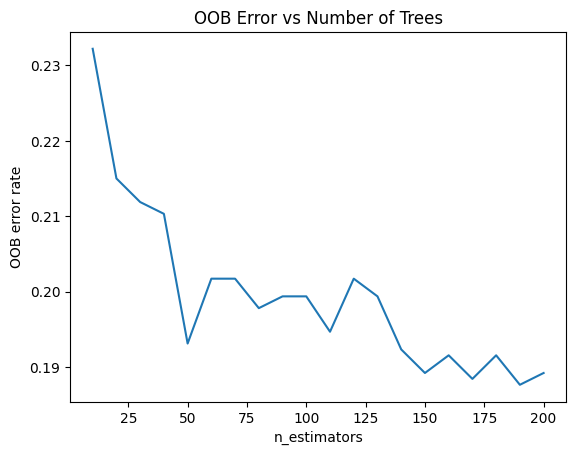

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

oob_errors = []
for n in range(10, 201, 10):
    model = RandomForestClassifier(n_estimators=n, oob_score=True, bootstrap=True, random_state=42)
    model.fit(X_train, y_train)
    oob_errors.append(1 - model.oob_score_)

plt.plot(range(10, 201, 10), oob_errors)
plt.xlabel('n_estimators')
plt.ylabel('OOB error rate')
plt.title('OOB Error vs Number of Trees')
plt.show()

## Feature Importance

In [ ]:
import pandas as pd

feature_importances = pd.Series(wine_cf.feature_importances_, index=X.columns)
feature_importances = feature_importances.sort_values(ascending=False)

print("Feature Importances:")
print(feature_importances)

Feature Importances:
alcohol                 0.146185
sulphates               0.141954
density                 0.120256
volatile acidity        0.105638
total sulfur dioxide    0.087654
fixed acidity           0.083337
pH                      0.077071
chlorides               0.070376
residual sugar          0.059566
free sulfur dioxide     0.058014
citric acid             0.049949
dtype: float64
